In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
from scipy.io import loadmat
from scipy.interpolate import griddata
from pathlib import Path
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.spatial import Delaunay
import numpy as np

### Data preparation

In [2]:
def prepare_lut_for_fitting(pmsm_lut: dict):
    id_vec = np.asarray(pmsm_lut["i_d_vec"]).ravel()
    iq_vec = np.asarray(pmsm_lut["i_q_vec"]).ravel()

    def fill_nans(arr2d):
        arr = arr2d.copy().astype(float)
        xi, yi = np.indices(arr.shape)
        mask = np.isnan(arr)
        if mask.any():
            arr[mask] = griddata(
                (xi[~mask], yi[~mask]), arr[~mask],
                (xi[mask],  yi[mask]),  method="nearest"
            )
        return arr

    psi_d_raw = fill_nans(np.asarray(pmsm_lut["Psi_d"]))
    psi_q_raw = fill_nans(np.asarray(pmsm_lut["Psi_q"]))
    L_dd_raw  = fill_nans(np.asarray(pmsm_lut["L_dd"]))
    L_dq_raw  = fill_nans(np.asarray(pmsm_lut["L_dq"]))
    L_qd_raw  = fill_nans(np.asarray(pmsm_lut["L_qd"]))
    L_qq_raw  = fill_nans(np.asarray(pmsm_lut["L_qq"]))

    psi_d_max = float(np.max(np.abs(psi_d_raw)))
    psi_q_max = float(np.max(np.abs(psi_q_raw)))
    i_max     = float(max(np.max(np.abs(id_vec)), np.max(np.abs(iq_vec))))
    L_dd_max  = float(np.max(np.abs(L_dd_raw)))
    L_qq_max  = float(np.max(np.abs(L_qq_raw)))
    L_dq_max  = float(np.max(np.abs(L_dq_raw)))   
    L_qd_max  = float(np.max(np.abs(L_qd_raw))) 

    norm = dict(
        psi_d_max=psi_d_max, psi_q_max=psi_q_max,
        L_dd_max=L_dd_max,   L_qq_max=L_qq_max,
        L_dq_max=L_dq_max,   L_qd_max=L_qd_max,
        i_max=i_max,
    )

    id_grid_pu = jnp.array(id_vec / i_max)
    iq_grid_pu = jnp.array(iq_vec / i_max)
    id_grid_A  = jnp.array(id_vec)
    iq_grid_A  = jnp.array(iq_vec)

    luts_pu = dict(
        psi_d=jnp.array(psi_d_raw.T / psi_d_max),
        psi_q=jnp.array(psi_q_raw.T / psi_q_max),
        L_dd =jnp.array(L_dd_raw.T  / L_dd_max),
        L_dq =jnp.array(L_dq_raw.T  / L_dq_max),
        L_qd =jnp.array(L_qd_raw.T  / L_qd_max),  
        L_qq =jnp.array(L_qq_raw.T  / L_qq_max),
    )
    luts_phys = dict(
        psi_d=jnp.array(psi_d_raw.T), psi_q=jnp.array(psi_q_raw.T),
        L_dd =jnp.array(L_dd_raw.T),  L_dq =jnp.array(L_dq_raw.T),
        L_qd =jnp.array(L_qd_raw.T),  L_qq =jnp.array(L_qq_raw.T),
    )
    return id_grid_pu, iq_grid_pu, id_grid_A, iq_grid_A, luts_pu, luts_phys, norm


notebook_dir = Path.cwd().parent
lut_raw = loadmat(notebook_dir / "exciting_environments/pmsm/LUT_BRUSA_jax_grad.mat")
id_grid_pu, iq_grid_pu, id_grid_A, iq_grid_A, luts_pu, luts_phys, norm = prepare_lut_for_fitting(lut_raw)
def prepare_lut_for_fitting(pmsm_lut: dict):
    id_vec = np.asarray(pmsm_lut["i_d_vec"]).ravel()
    iq_vec = np.asarray(pmsm_lut["i_q_vec"]).ravel()
 
    def fill_nans(arr2d):
        arr = arr2d.copy().astype(float)
        xi, yi = np.indices(arr.shape)
        mask = np.isnan(arr)
        if mask.any():
            arr[mask] = griddata(
                (xi[~mask], yi[~mask]), arr[~mask],
                (xi[mask],  yi[mask]),  method="nearest"
            )
        return arr
 
    psi_d_raw = fill_nans(np.asarray(pmsm_lut["Psi_d"]))   
    psi_q_raw = fill_nans(np.asarray(pmsm_lut["Psi_q"]))
 
    psi_d_data = psi_d_raw.T   
    psi_q_data = psi_q_raw.T
 
    norm = dict(
        psi_d_max=float(np.max(np.abs(psi_d_data))),
        psi_q_max=float(np.max(np.abs(psi_q_data))),
        i_d_min=float(id_vec.min()),
        i_d_max=float(id_vec.max()),
        i_q_min=float(iq_vec.min()),
        i_q_max=float(iq_vec.max()),
    )
 
 
    return id_vec, iq_vec, psi_d_data, psi_q_data, norm

In [3]:
notebook_dir = Path.cwd().parent
lut_raw = loadmat(
    notebook_dir / "exciting_environments/pmsm/LUT_BRUSA_jax_grad.mat"
)

id_vec, iq_vec, psi_d_data, psi_q_data, norm = prepare_lut_for_fitting(lut_raw)

### PWA Training and transfer to JAX

In [4]:
def fit_pwa_flux_map(
    id_vec,
    iq_vec,
    psi_d_data,
    psi_q_data,
    n_grid_d=5,
    n_grid_q=7,
    eps=1e-4,
    w_smooth=0.0,
    verbose=True,
):
   
    ID_s, IQ_s = np.meshgrid(id_vec, iq_vec, indexing='ij')
    samples_i   = np.stack([ID_s.ravel(), IQ_s.ravel()], axis=1)  
    samples_lam = np.stack([
        psi_d_data.ravel(),
        psi_q_data.ravel()
    ], axis=1) 
    NS = len(samples_i)
 
    id_pts = np.linspace(id_vec.min(), id_vec.max(), n_grid_d)
    iq_pts = np.linspace(iq_vec.min(), iq_vec.max(), n_grid_q)
    ID_v, IQ_v = np.meshgrid(id_pts, iq_pts, indexing='ij')
    vertices = np.stack([ID_v.ravel(), IQ_v.ravel()], axis=1)  
    NP = len(vertices)
    tri      = Delaunay(vertices)
    simplices = tri.simplices  
    NM       = len(simplices)
    simplex_idx = tri.find_simplex(samples_i)
 

    Lambda_hat = cp.Variable((NP, 2))
 
    cost        = 0.0
    constraints = []

    if w_smooth > 0:
        neighbors = {}
        for j in range(NM):
            for k in range(NM):
                if j >= k:
                    continue
                shared = set(simplices[j]) & set(simplices[k])
                if len(shared) == 2:  
                    neighbors[(j, k)] = True
 
    for j in range(NM):
        v_idx   = simplices[j]          
        I_verts = vertices[v_idx]      
 
        M_I = (I_verts[1:] - I_verts[0]).T 

        Lam_verts = Lambda_hat[v_idx, :]
 

        M_Lam = (Lam_verts[1:, :] - Lam_verts[0:1, :]).T   
 

        M_I_inv = np.linalg.inv(M_I)
        L_j = M_Lam @ M_I_inv  
 

        psi_j = Lam_verts[0, :] - L_j @ I_verts[0] 
 

        constraints.append(L_j + L_j.T >> 2 * eps * np.eye(2))
 
        mask = (simplex_idx == j)
        if mask.sum() == 0:
            continue
 
        i_s   = samples_i[mask]    
        lam_s = samples_lam[mask]  
 
        lam_hat_s = (L_j @ i_s.T).T + psi_j   
 
        residuals = lam_hat_s - lam_s          
        cost += cp.sum_squares(residuals)
 
    if w_smooth > 0:
        for (j, k) in neighbors:
            v_j = simplices[j]
            v_k = simplices[k]
 
            M_I_j   = (vertices[v_j[1:]] - vertices[v_j[0]]).T
            M_I_k   = (vertices[v_k[1:]] - vertices[v_k[0]]).T
            M_Lam_j = (Lambda_hat[v_j[1:], :] - Lambda_hat[v_j[0:1], :]).T
            M_Lam_k = (Lambda_hat[v_k[1:], :] - Lambda_hat[v_k[0:1], :]).T
 
            L_j_s = M_Lam_j @ np.linalg.inv(M_I_j)
            L_k_s = M_Lam_k @ np.linalg.inv(M_I_k)
 
            cost += w_smooth * cp.sum_squares(L_j_s - L_k_s)
 
    prob = cp.Problem(cp.Minimize(cost), constraints)
 
    solved = False
    for solver in [cp.CLARABEL, cp.SCS]:
        try:
            prob.solve(solver=solver, verbose=verbose)
            if prob.status in ["optimal", "optimal_inaccurate"]:
                if verbose:
                    print(f"  solver: {solver}  status: {prob.status}")
                    print(f"  costs: {prob.value:.6e}")
                solved = True
                break
        except Exception as e:
            if verbose:
                print(f"  {solver} fehlgeschlagen: {e}")
            continue
 
    if not solved:
        raise RuntimeError("No Solver succeeded!")
 
    Lam_opt = Lambda_hat.value   
 
    L_list   = []
    psi_list = []
    for j in range(NM):
        v_idx    = simplices[j]
        I_verts  = vertices[v_idx]
        Lam_verts = Lam_opt[v_idx]
 
        M_I   = (I_verts[1:]  - I_verts[0]).T
        M_Lam = (Lam_verts[1:] - Lam_verts[0]).T
 
        L_j   = M_Lam @ np.linalg.inv(M_I)
        psi_j = Lam_verts[0] - L_j @ I_verts[0]
 
        L_list.append(L_j)
        psi_list.append(psi_j)
 
    return {
        "vertices_I":   vertices,          
        "vertices_Lam": Lam_opt,           
        "simplices":    simplices,          
        "L_all":        np.stack(L_list),   
        "psi_all":      np.stack(psi_list),
        "tri":          tri,              
        "cost":         prob.value,
    }

In [5]:
def build_jax_pwa(pwa_params):
   
    return {
        "vertices_I": jnp.array(pwa_params["vertices_I"]),   
        "simplices":  jnp.array(pwa_params["simplices"]),   
        "L_all":      jnp.array(pwa_params["L_all"]),        # 
        "psi_all":    jnp.array(pwa_params["psi_all"]),     
    }
 
 
def _find_simplex_jax(i_query, vertices_I, simplices):
    def check_simplex(j):
        v_idx   = simplices[j]
        I_verts = vertices_I[v_idx]
        T   = (I_verts[1:] - I_verts[0]).T
        rhs = i_query - I_verts[0]
        lam = jnp.linalg.solve(T, rhs)
        lam_full = jnp.array([1.0 - lam[0] - lam[1], lam[0], lam[1]])

        return jnp.min(lam_full)

    NM = simplices.shape[0]
    scores = jax.vmap(check_simplex)(jnp.arange(NM))
    return jnp.argmax(scores)
 
 
@jax.jit
def pwa_flux(id_A, iq_A, vertices_I, simplices, L_all, psi_all):
    i_query = jnp.array([id_A, iq_A])
 
    j     = _find_simplex_jax(i_query, vertices_I, simplices)
    L_j   = L_all[j]    
    psi_j = psi_all[j]   
 
    lam = L_j @ i_query + psi_j
    return lam[0], lam[1]
 
 
@jax.jit
def pwa_inductances(id_A, iq_A, vertices_I, simplices, L_all, psi_all):
    i_query = jnp.array([id_A, iq_A])
    j       = _find_simplex_jax(i_query, vertices_I, simplices)
    L_j     = L_all[j] 
    return L_j[0, 0], L_j[1, 1], L_j[0, 1], L_j[1, 0]
 
 
def pwa_flux_grid(id_grid, iq_grid, jax_params):
    
    vI  = jax_params["vertices_I"]
    sim = jax_params["simplices"]
    L   = jax_params["L_all"]
    psi = jax_params["psi_all"]
 
    psi_d, psi_q = jax.vmap(
        jax.vmap(pwa_flux, (None, 0, None, None, None, None)),
        (0, None, None, None, None, None)
    )(id_grid, iq_grid, vI, sim, L, psi)
 
    return psi_d, psi_q   
 
 

def evaluate_pwa_error(jax_params, id_grid_A, iq_grid_A, psi_d_ref, psi_q_ref):
    psi_d_hat, psi_q_hat = pwa_flux_grid(
        jnp.array(id_grid_A),
        jnp.array(iq_grid_A),
        jax_params
    )
 
    psi_d_ref_j = jnp.array(psi_d_ref)
    psi_q_ref_j = jnp.array(psi_q_ref)
 
    eps_d = jnp.abs(psi_d_hat - psi_d_ref_j) / jnp.max(jnp.abs(psi_d_ref_j)) * 100.0
    eps_q = jnp.abs(psi_q_hat - psi_q_ref_j) / jnp.max(jnp.abs(psi_q_ref_j)) * 100.0
 
    print(f"  psi_d: max = {eps_d.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_d**2)):.2f}%")
    print(f"  psi_q: max = {eps_q.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_q**2)):.2f}%")
 
    return eps_d, eps_q

In [31]:

pwa_params = fit_pwa_flux_map(
    id_vec, iq_vec,
    psi_d_data, psi_q_data,
    n_grid_d=11,      
    n_grid_q=15,
    eps=1e-4,
    w_smooth=0.0,  
    verbose=True,
)

jax_params = build_jax_pwa(pwa_params)

id_test, iq_test = -50.0, 100.0
psi_d, psi_q = pwa_flux(
    id_test, iq_test,
    jax_params["vertices_I"],
    jax_params["simplices"],
    jax_params["L_all"],
    jax_params["psi_all"],
)
print(f"\n Single Point:")
print(f"  id={id_test} A, iq={iq_test} A")
print(f"  psi_d = {float(psi_d):.4f} Vs")
print(f"  psi_q = {float(psi_q):.4f} Vs")

L_dd, L_qq, L_dq, L_qd = pwa_inductances(
    id_test, iq_test,
    jax_params["vertices_I"],
    jax_params["simplices"],
    jax_params["L_all"],
    jax_params["psi_all"],
)
print(f"  L_dd = {float(L_dd)*1000:.3f} mH")
print(f"  L_qq = {float(L_qq)*1000:.3f} mH")
print(f"  L_dq = {float(L_dq)*1000:.3f} mH")

eps_d, eps_q = evaluate_pwa_error(
    jax_params,
    id_vec, iq_vec,
    psi_d_data, psi_q_data
)

/tmp/ipykernel_86726/1312032590.py:95: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(cp.Minimize(cost), constraints)
(CVXPY) May 21 12:19:21 PM: Your problem has 330 variables, 1120 constraints, and 0 parameters.
(CVXPY) May 21 12:19:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 21 12:19:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 21 12:19:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 21 12:19:21 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 21 12:19:21 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) May 21 12:19:21 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) May 21 12:19:21 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.8.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 21 12:19:21 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 21 12:19:21 PM: Applying reduction ConeMatrixStuffing
/tmp/ipykernel_86726/1312032590.py:100: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  prob.solve(solver=solver, verbose=verbose)
(CVXPY) May 21 12:19:22 PM: Applying reduction CLARABEL
(CVXPY) May 21 12:19:22 PM: Finished problem compilation (took 1.771e+00 seconds).
(CVXPY) May 21 12:19:22 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 2982
  constraints   = 3492
  nnz(P)        = 2652
  nnz(A)        = 12296
  cones (total) = 281
    :        Zero = 1,  numel = 2652
    : PSDTriangle = 280,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9

(CVXPY) May 21 12:19:23 PM: Problem status: optimal
(CVXPY) May 21 12:19:23 PM: Optimal value: 3.017e-04
(CVXPY) May 21 12:19:23 PM: Compilation took 1.771e+00 seconds
(CVXPY) May 21 12:19:23 PM: Solver (including time spent in interface) took 1.300e-02 seconds


  0  +1.1823e-03  +1.7056e+00  1.70e+00  4.92e-01  4.10e-02  1.00e+00  1.05e+00   ------   
  1  +2.0198e-02  +1.1553e-01  9.53e-02  1.55e-01  3.20e-02  2.53e-03  7.99e-01  5.08e-01  
  2  +1.3684e-03  +9.9250e-03  8.56e-03  2.03e-02  2.70e-02  3.35e-02  5.87e-01  9.90e-01  
  3  +6.5791e-04  +2.7483e-03  2.09e-03  2.66e-03  8.55e-03  6.52e-03  1.49e-01  8.19e-01  
  4  +3.2325e-04  +1.7304e-04  1.50e-04  1.41e-04  1.01e-03  5.64e-04  1.53e-02  9.45e-01  
  5  +3.0212e-04  +2.7365e-04  2.85e-05  3.18e-06  2.71e-05  2.15e-05  6.49e-04  9.77e-01  
  6  +3.0169e-04  +3.0083e-04  8.68e-07  3.24e-08  2.78e-07  4.27e-07  1.34e-05  9.90e-01  
  7  +3.0169e-04  +3.0168e-04  9.92e-09  3.24e-10  2.78e-09  4.75e-09  1.49e-07  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 10.706795ms
-------------------------------------------------------------------------------
                                 

## GT Comparison

In [25]:
def plot_fit_comparison_pwa(jax_params, id_grid_A, iq_grid_A, psi_d_ref, psi_q_ref, luts_phys):

    vI  = jax_params["vertices_I"]
    sim = jax_params["simplices"]
    L   = jax_params["L_all"]
    psi = jax_params["psi_all"]

    psi_d_hat, psi_q_hat = jax.vmap(
        jax.vmap(pwa_flux, (None, 0, None, None, None, None)),
        (0, None, None, None, None, None)
    )(jnp.array(id_grid_A), jnp.array(iq_grid_A), vI, sim, L, psi)

    Ldd_hat, Lqq_hat, Ldq_hat, Lqd_hat = jax.vmap(
        jax.vmap(pwa_inductances, (None, 0, None, None, None, None)),
        (0, None, None, None, None, None)
    )(jnp.array(id_grid_A), jnp.array(iq_grid_A), vI, sim, L, psi)

    id_arr = jnp.array(id_grid_A, dtype=jnp.float32)
    iq_arr = jnp.array(iq_grid_A, dtype=jnp.float32)

    interp_psi_d_gt = jax.scipy.interpolate.RegularGridInterpolator(
        (id_arr, iq_arr), jnp.array(psi_d_ref, dtype=jnp.float32), method='linear'
    )
    interp_psi_q_gt = jax.scipy.interpolate.RegularGridInterpolator(
        (id_arr, iq_arr), jnp.array(psi_q_ref, dtype=jnp.float32), method='linear'
    )

    def psi_d_fn(id_val, iq_val):
        return interp_psi_d_gt(jnp.array([id_val, iq_val]))[0]

    def psi_q_fn(id_val, iq_val):
        return interp_psi_q_gt(jnp.array([id_val, iq_val]))[0]

    grad_psi_d = jax.vmap(
        jax.vmap(jax.grad(psi_d_fn, argnums=(0, 1)), (None, 0)), (0, None)
    )(id_arr, iq_arr)
    grad_psi_q = jax.vmap(
        jax.vmap(jax.grad(psi_q_fn, argnums=(0, 1)), (None, 0)), (0, None)
    )(id_arr, iq_arr)

    Ldd_gt = grad_psi_d[0]
    Ldq_gt = grad_psi_d[1]
    Lqd_gt = grad_psi_q[0]
    Lqq_gt = grad_psi_q[1]

    psi_d_ref_j = jnp.array(psi_d_ref)
    psi_q_ref_j = jnp.array(psi_q_ref)

    eps_d   = jnp.abs(psi_d_hat - psi_d_ref_j) / jnp.max(jnp.abs(psi_d_ref_j)) * 100
    eps_q   = jnp.abs(psi_q_hat - psi_q_ref_j) / jnp.max(jnp.abs(psi_q_ref_j)) * 100
    eps_Ldd = jnp.abs(Ldd_hat - Ldd_gt) / jnp.max(jnp.abs(luts_phys["L_dd"])) * 100
    eps_Lqq = jnp.abs(Lqq_hat - Lqq_gt) / jnp.max(jnp.abs(luts_phys["L_qq"])) * 100
    eps_Ldq = jnp.abs(Ldq_hat - Ldq_gt) / jnp.max(jnp.abs(luts_phys["L_dq"])) * 100
    eps_Lqd = jnp.abs(Lqd_hat - Lqd_gt) / jnp.max(jnp.abs(luts_phys["L_qd"])) * 100

    ID, IQ = np.meshgrid(np.array(id_grid_A), np.array(iq_grid_A), indexing='ij')
    NM = len(jax_params["simplices"])
    NP = len(jax_params["vertices_I"])

    def surf(ax, data, title, cmap='viridis'):
        ax.plot_surface(ID, IQ, np.array(data), cmap=cmap, alpha=0.85)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('i_d')
        ax.set_ylabel('i_q')


    fig1 = plt.figure(figsize=(15, 7))
    surf(fig1.add_subplot(231, projection='3d'), psi_d_ref_j, 'Psi_d LUT (GT)')
    surf(fig1.add_subplot(232, projection='3d'), psi_d_hat,   'Psi_d PWA')
    surf(fig1.add_subplot(233, projection='3d'), eps_d,       'Error in % of max')
    surf(fig1.add_subplot(234, projection='3d'), psi_q_ref_j, 'Psi_q LUT (GT)',  'plasma')
    surf(fig1.add_subplot(235, projection='3d'), psi_q_hat,   'Psi_q PWA',       'plasma')
    surf(fig1.add_subplot(236, projection='3d'), eps_q,       'Error Psi_q in % of max')
    fig1.suptitle(
        f'PWA Flux Map ({NP} Vertices, {NM} Simplices) '
        f'(max_d={float(eps_d.max()):.2f}%  max_q={float(eps_q.max()):.2f}%)',
        fontsize=12
    )
    plt.tight_layout()


    rows = [
        (luts_phys["L_dd"]*1e3, Ldd_gt*1e3, Ldd_hat*1e3, eps_Ldd, 'Ldd'),
        (luts_phys["L_qq"]*1e3, Lqq_gt*1e3, Lqq_hat*1e3, eps_Lqq, 'Lqq'),
        (luts_phys["L_dq"]*1e3, Ldq_gt*1e3, Ldq_hat*1e3, eps_Ldq, 'Ldq'),
        (luts_phys["L_qd"]*1e3, Lqd_gt*1e3, Lqd_hat*1e3, eps_Lqd, 'Lqd'),
    ]

    fig3 = plt.figure(figsize=(20, 12))
    for row_idx, (gt_lut, gt_grad, fit, err, label) in enumerate(rows):
        surf(fig3.add_subplot(4, 4, row_idx*4+1, projection='3d'), gt_lut,  f'{label} GT LUT')
        surf(fig3.add_subplot(4, 4, row_idx*4+2, projection='3d'), gt_grad, f'{label} GT dpsi/di')
        surf(fig3.add_subplot(4, 4, row_idx*4+3, projection='3d'), fit,     f'{label} PWA')
        surf(fig3.add_subplot(4, 4, row_idx*4+4, projection='3d'), err,     f'Error {label} in % of max')

    plt.tight_layout()
    plt.show()
    print((Ldq_hat - Lqd_hat).max())

In [9]:
jax_params["simplices"].shape

(280, 3)

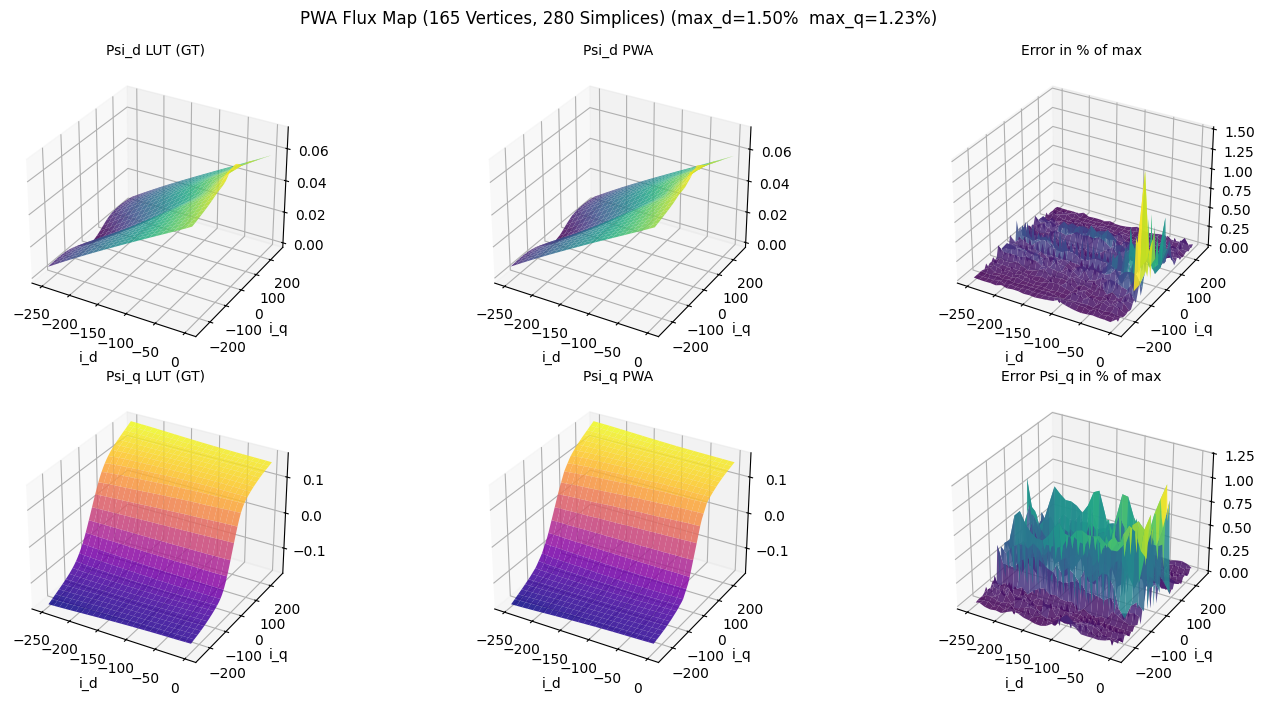

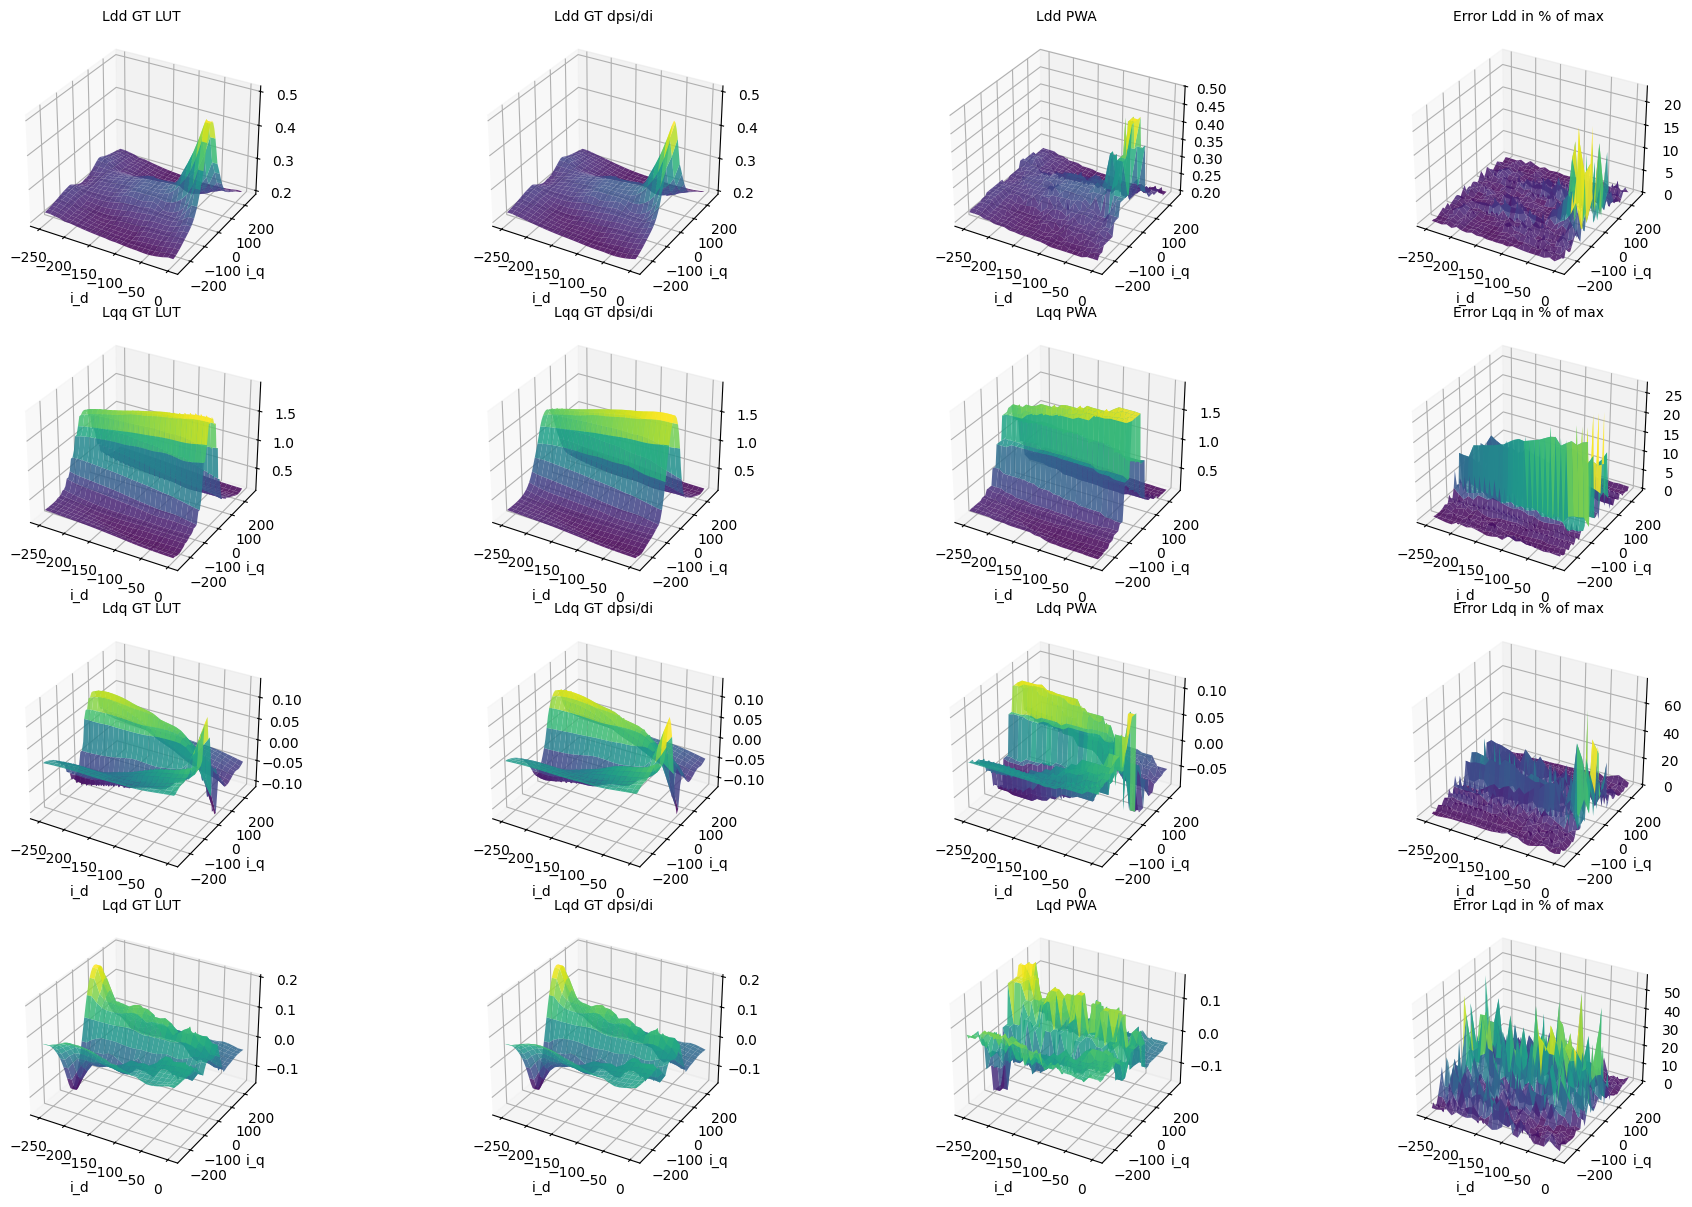

8.777102e-05


In [32]:
plot_fit_comparison_pwa(
    jax_params,
    id_vec, iq_vec,
    psi_d_data, psi_q_data,
    luts_phys
)

## PMSM Implementation

In [11]:
import equinox as eqx
import jax.numpy as jnp
from exciting_environments.pmsm import PMSM, MotorVariant
from exciting_environments import EnvironmentRegistry

class SatPMSM_PWA(PMSM):

    _vertices_I : jax.Array
    _simplices  : jax.Array
    _L_all      : jax.Array
    _psi_all    : jax.Array

    def __init__(self, pwa_params: dict, **kwargs):
        super().__init__(**kwargs)
        self._vertices_I = pwa_params["vertices_I"]
        self._simplices  = pwa_params["simplices"]
        self._L_all      = pwa_params["L_all"]
        self._psi_all    = pwa_params["psi_all"]

    def _find_simplex(self, i_query):
        def check_simplex(j):
            v_idx    = self._simplices[j]
            I_verts  = self._vertices_I[v_idx]
            T        = (I_verts[1:] - I_verts[0]).T
            lam      = jnp.linalg.solve(T, i_query - I_verts[0])
            lam_full = jnp.array([1.0 - lam[0] - lam[1], lam[0], lam[1]])
            return jnp.min(lam_full)

        scores = jax.vmap(check_simplex)(jnp.arange(self._simplices.shape[0]))
        return jnp.argmax(scores)

    def _psi_dq(self, i_d, i_q):
        i_query = jnp.array([i_d, i_q])
        j       = self._find_simplex(i_query)
        lam     = self._L_all[j] @ i_query + self._psi_all[j]
        return lam[0], lam[1]

    def _inductances(self, i_d, i_q):
        i_query = jnp.array([i_d, i_q])
        j       = self._find_simplex(i_query)
        L_j     = self._L_all[j]
        return L_j[0, 0], L_j[1, 1], L_j[0, 1], L_j[1, 0]

    def currents_to_torque_saturated(self, i_d, i_q):
        psi_d, psi_q = self._psi_dq(i_d, i_q)
        return 3 / 2 * self.env_properties.static_params.p * (psi_d * i_q - psi_q * i_d)

    def nonlinear_ode(self, t, y, args, action):
        i_d, i_q, eps = y
        static_params, omega_el = args
        u_dq = action(t)

        J_k  = jnp.array([[0, -1], [1, 0]])
        i_dq = jnp.array([i_d, i_q])

        psi_d, psi_q            = self._psi_dq(i_d, i_q)
        L_dd, L_qq, L_dq, L_qd = self._inductances(i_d, i_q)

        L_diff_inv = jnp.linalg.inv(jnp.array([[L_dd, L_dq],
                                                [L_qd, L_qq]]))
        di_dq = L_diff_inv @ (u_dq
                               - static_params.r_s * i_dq
                               - omega_el * J_k @ jnp.array([psi_d, psi_q]))

        return di_dq[0], di_dq[1], omega_el

jax_pwa = build_jax_pwa(pwa_params)  
sat_pmsm = SatPMSM_PWA(
    jax_pwa,
    saturated=True,
    motor_variant=MotorVariant.BRUSA,
)

pmsm = EnvironmentRegistry.PMSM.make(
    saturated=True, motor_variant=MotorVariant.BRUSA
)

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [12]:
import time
from functools import partial

In [13]:
def rollout_const(env, init_state, act, n_steps):
    def scan_fn(state, _):
        obs, next_state = env.step(state, act)
        loss = jnp.sum(obs[0:2] ** 2)
        return next_state, loss
    _, losses = jax.lax.scan(scan_fn, init_state, None, length=n_steps)
    return jnp.sum(losses)

def rollout_seq(env, init_state, acts, n_steps):
    def scan_fn(state, act):
        obs, next_state = env.step(state, act)
        loss = jnp.sum(obs[0:2] ** 2)
        return next_state, loss
    _, losses = jax.lax.scan(scan_fn, init_state, acts)
    return jnp.sum(losses)


@partial(jax.jit, static_argnums=(2,))
def fwd_const_pmsm(state, act, n_steps):
    return rollout_const(pmsm, state, act, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_const_sat(state, act, n_steps):
    return rollout_const(sat_pmsm, state, act, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_seq_pmsm(state, acts, n_steps):
    return rollout_seq(pmsm, state, acts, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_seq_sat(state, acts, n_steps):
    return rollout_seq(sat_pmsm, state, acts, n_steps)

@partial(jax.jit, static_argnums=(2,))
def bwd_const_pmsm(state, act, n_steps):
    return jax.grad(lambda a: rollout_const(pmsm, state, a, n_steps))(act)

@partial(jax.jit, static_argnums=(2,))
def bwd_const_sat(state, act, n_steps):
    return jax.grad(lambda a: rollout_const(sat_pmsm, state, a, n_steps))(act)

@partial(jax.jit, static_argnums=(2,))
def bwd_seq_pmsm(state, acts, n_steps):
    return jax.grad(lambda a: rollout_seq(pmsm, state, a, n_steps))(acts)

@partial(jax.jit, static_argnums=(2,))
def bwd_seq_sat(state, acts, n_steps):
    return jax.grad(lambda a: rollout_seq(sat_pmsm, state, a, n_steps))(acts)



key = jax.random.PRNGKey(0)
act_const = jnp.array([0.03, 0.03])
_, state     = pmsm.reset()
_, state_sat = sat_pmsm.reset()



print("Warm-up...")
for n_steps in [1, 10, 50, 100, 500]:
    acts_seq = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1)

    jax.block_until_ready(fwd_const_pmsm(state,     act_const, n_steps))
    jax.block_until_ready(fwd_const_sat( state_sat, act_const, n_steps))
    jax.block_until_ready(bwd_const_pmsm(state,     act_const, n_steps))
    jax.block_until_ready(bwd_const_sat( state_sat, act_const, n_steps))
    jax.block_until_ready(fwd_seq_pmsm(  state,     acts_seq,  n_steps))
    jax.block_until_ready(fwd_seq_sat(   state_sat, acts_seq,  n_steps))
    jax.block_until_ready(bwd_seq_pmsm(  state,     acts_seq,  n_steps))
    jax.block_until_ready(bwd_seq_sat(   state_sat, acts_seq,  n_steps))
print("Warm-up done.\n")



N = 50

def measure(fn, *args):
    t0 = time.perf_counter()
    for _ in range(N):
        out = fn(*args)
    jax.block_until_ready(jax.tree_util.tree_leaves(out))
    return (time.perf_counter() - t0) / N * 1000

sep    = "=" * 60
header = f"  {'n_steps':>8}    {'PMSM':>10}      {'PMSM PWA':>10} " #{'Overhead':>8}

for label, fwd_p, fwd_s, bwd_p, bwd_s, use_seq in [
    # ("const action", fwd_const_pmsm, fwd_const_sat, bwd_const_pmsm, bwd_const_sat, False),
    ("seq actions",  fwd_seq_pmsm,   fwd_seq_sat,   bwd_seq_pmsm,   bwd_seq_sat,   True),
]:
    #print(sep)
    print(f"  {label}")
    print(sep)
    print(header)
    print("-" * 60)

    print("  ── Forward ──")
    for n_steps in [1, 10, 50, 100, 500]:
        acts = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1) if use_seq else act_const
        t_p = measure(fwd_p, state,     acts, n_steps)
        t_s = measure(fwd_s, state_sat, acts, n_steps)
        print(f"  n={n_steps:4d}       {t_p:8.3f} ms  {t_s:8.3f} ms") #{t_s/t_p:6.2f}x

    print("  ── Backward dloss/dacts ──")
    for n_steps in [1, 10, 50, 100, 500]:
        acts = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1) if use_seq else act_const
        t_p = measure(bwd_p, state,     acts, n_steps)
        t_s = measure(bwd_s, state_sat, acts, n_steps)
        print(f"  n={n_steps:4d}       {t_p:8.3f} ms  {t_s:8.3f} ms  ") #{t_s/t_p:6.2f}x

print(sep)

Warm-up...
Warm-up done.

  seq actions
   n_steps          PMSM        PMSM PWA 
------------------------------------------------------------
  ── Forward ──
  n=   1          0.083 ms     0.117 ms
  n=  10          0.463 ms     0.739 ms
  n=  50          2.211 ms     3.550 ms
  n= 100          4.393 ms     7.056 ms
  n= 500         22.081 ms    35.477 ms
  ── Backward dloss/dacts ──
  n=   1          0.038 ms     0.036 ms  
  n=  10          1.649 ms     1.055 ms  
  n=  50          8.098 ms     5.136 ms  
  n= 100         16.243 ms    10.241 ms  
  n= 500         80.740 ms    51.039 ms  
